In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('/content/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
#CLEANING + EDA

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()#calculating mean of numerical data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.duplicated().sum()#checking the no of duplicates

np.int64(0)

In [9]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


In [10]:
#we can use the above data for prediction bcxz of lets take an example
"""918col =  850cancercol + 68non_cancer
if we train our model to the 850:68 then our model will be trained for more cancer patients"""

'918col =  850cancercol + 68non_cancer\nif we train our model to the 850:68 then our model will be trained for more cancer patients'

<Axes: xlabel='HeartDisease'>

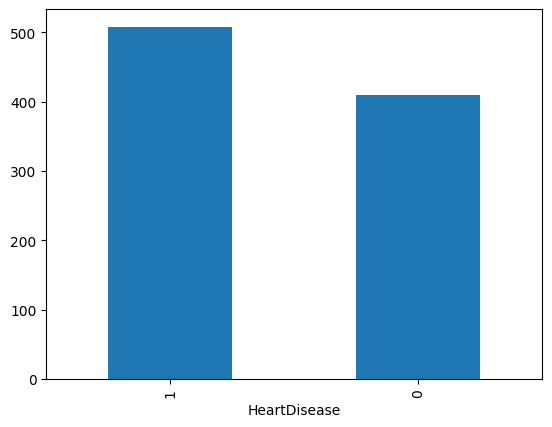

In [11]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [12]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


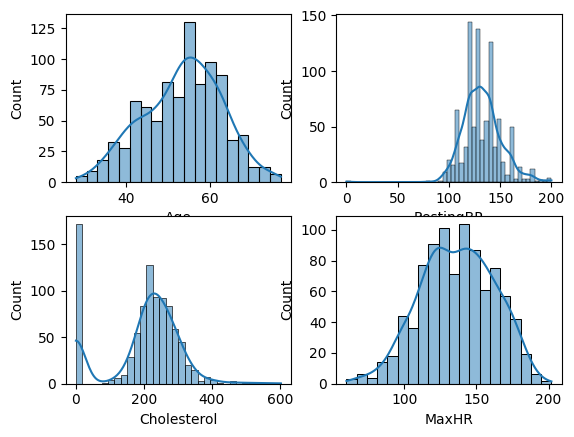

In [13]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)#target variable

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

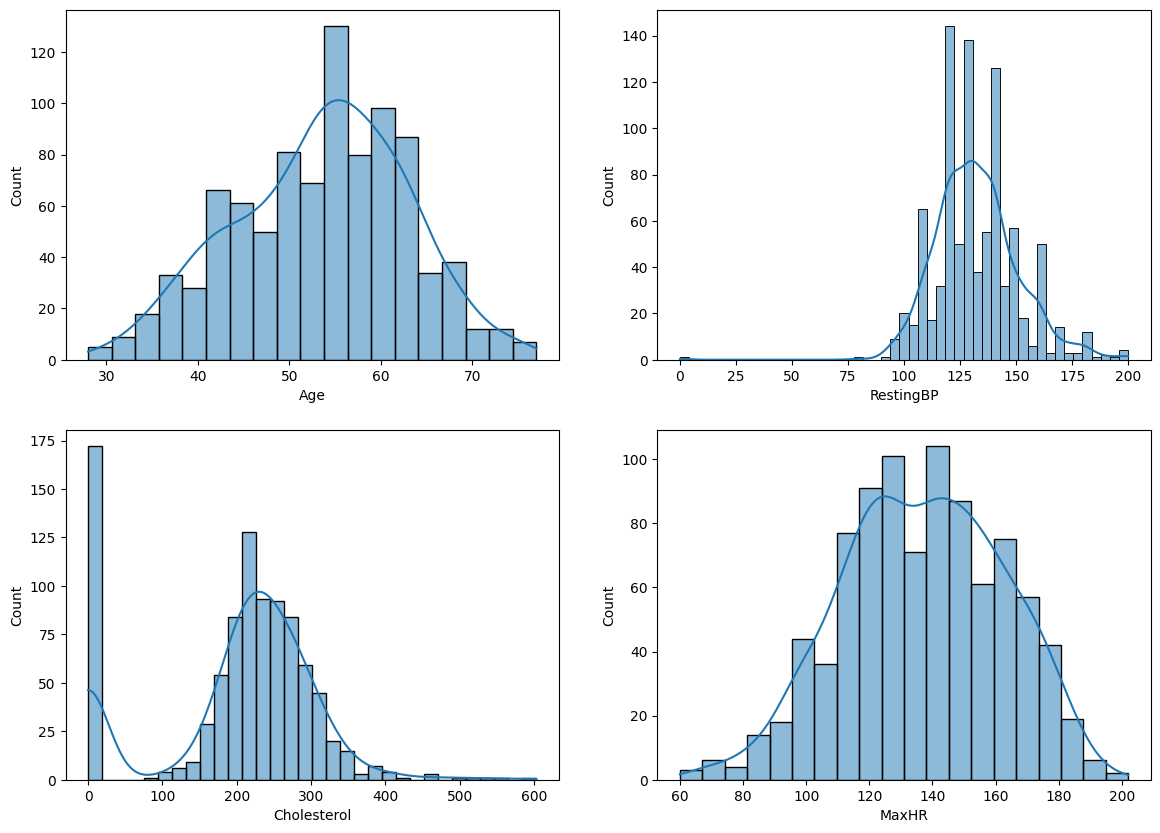

In [14]:
def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True)

# Set figure size once
plt.figure(figsize=(14, 10))

# Call the functions
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

 # pad adds extra spacing
plt.show()

In [15]:
#from the above rstingbp histplot there is a not a chance of resting bp =0
#then we should remove the anamoly

In [16]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [17]:
"""there is not a duplicate/null value but there is a wrong value which can affect our accuracy score """

'there is not a duplicate/null value but there is a wrong value which can affect our accuracy score '

In [18]:
"""Possibility may arise when the person has a downloaded the data the had edit the zero to value at missing value index to make the data more precise or make look precise or may look more confident."""

'Possibility may arise when the person has a downloaded the data the had edit the zero to value at missing value index to make the data more precise or make look precise or may look more confident.'

In [20]:
#we will fill the 0 value data into mean value with normal data
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [22]:
#we will fill the 0 value with 244
#distribution now will also look alike the previous one but now our machine learning algorithm is not playing with our outliers # not possiblle value
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(2)


In [23]:

resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)

df['RestingBP'] = df['RestingBP'].round(2)

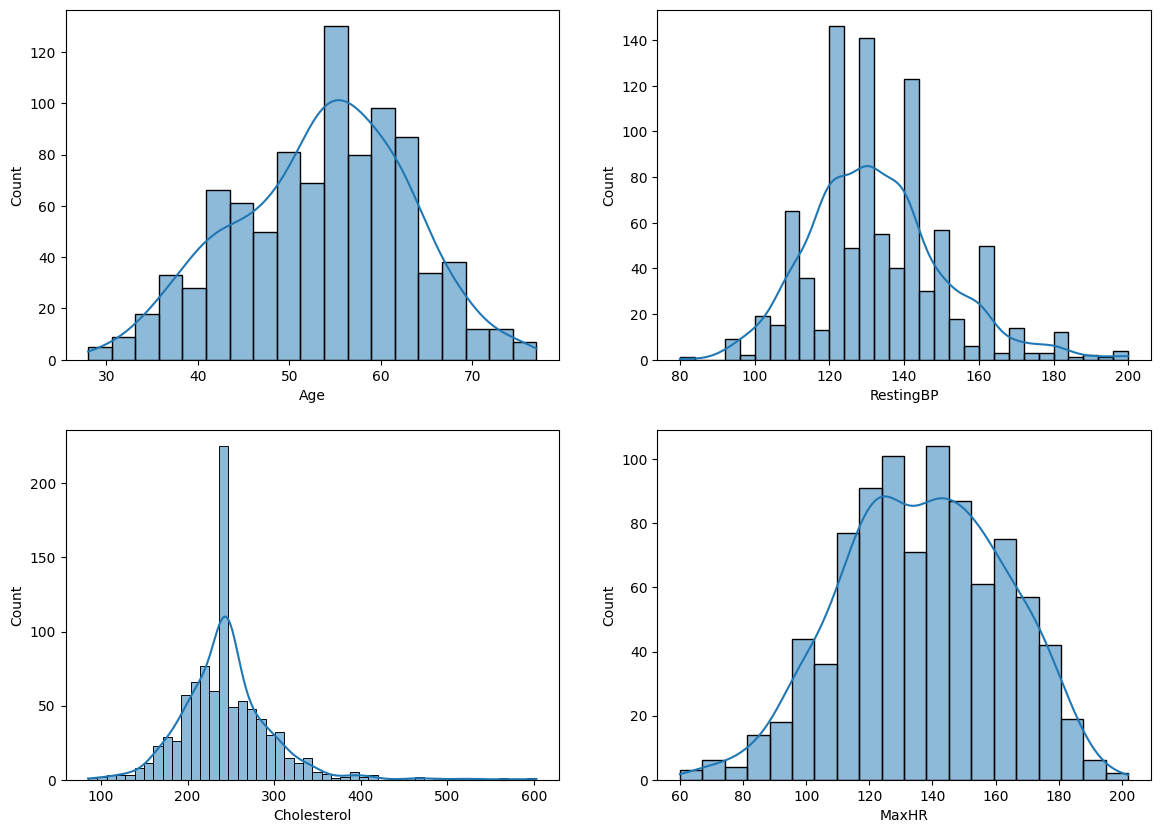

In [25]:
def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True)

# Set figure size once
plt.figure(figsize=(14, 10))

# Call the functions
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

 # pad adds extra spacing
plt.show()

In [29]:
#analysis of categorical variables

!pip install sheryanalysis==0.1.0

In [ ]:
import shreyanalysis as sh
sh.analyze()

<Axes: xlabel='Sex', ylabel='count'>

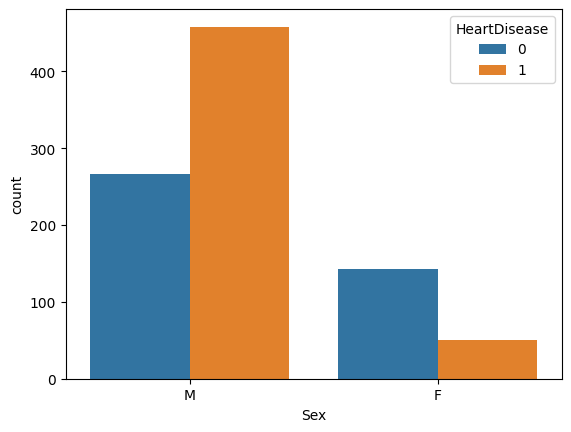

In [36]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])
#anamoly-male>female

<Axes: xlabel='FastingBS', ylabel='count'>

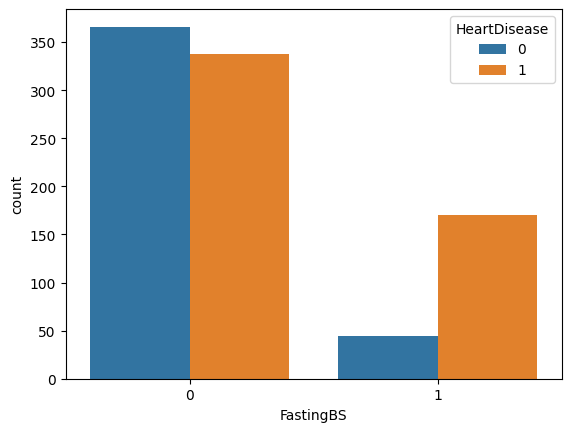

In [37]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

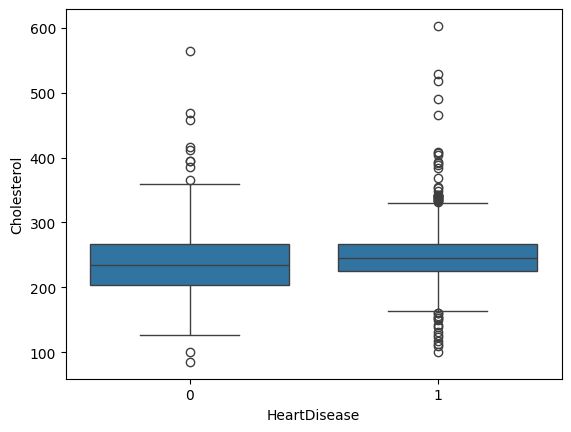

In [39]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

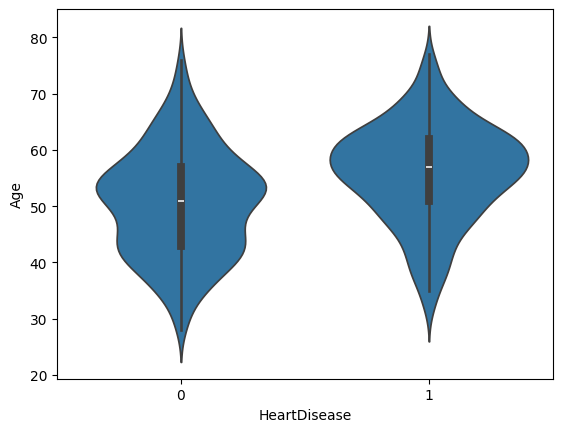

In [40]:
sns.violinplot(x='HeartDisease', y='Age', data=df)


<Axes: >

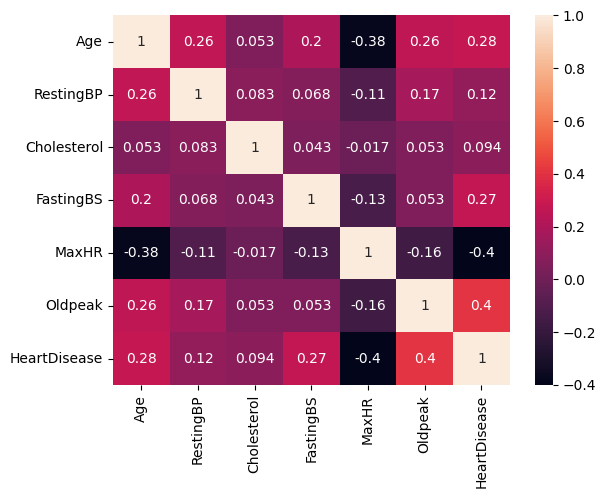

In [41]:
sns.heatmap(df.corr(numeric_only=True), annot=True)


In [42]:
"""besides the relation with the heart disease with age is good resting BP is good, but cholesterol is not so good, but therefore we will also use cholesterol because it may give some good relation with other columns like fasting bp Max HR old beak etc  """

'besides the relation with the heart disease with age is good resting BP is good, but cholesterol is not so good, but therefore we will also use cholesterol because it may give some good relation with other columns like fasting bp Max HR old beak etc  '

In [ ]:
#DATA PREPROCESSING AND CLEANING

In [ ]:
#CLEANING IS DONE BCZ HE HAD ALREADY REMOVED THE ZERO AND DUPLICATE VALUES

In [45]:
"""What pd.get_dummies() Does
This function performs One-Hot Encoding. It takes columns with strings or categories (like "Color") and turns them into multiple columns of 1s and 0s.

1 represents the presence of that category.

0 represents the absence.

The Power of drop_first=True
This is the most important part of your snippet.
By setting this to True, you are avoiding the Dummy Variable Trap (multicollinearity).

If you have a "Gender" column with Male and Female,
one-hot encoding usually creates two columns.
However, if Is_Male is 0, we already know the person is female.
Having both columns is redundant and can confuse some models (like Linear Regression)
because the variables become perfectly predictable from one another."""

'What pd.get_dummies() Does\nThis function performs One-Hot Encoding. It takes columns with strings or categories (like "Color") and turns them into multiple columns of 1s and 0s.\n\n1 represents the presence of that category.\n\n0 represents the absence.\n\nThe Power of drop_first=True\nThis is the most important part of your snippet. \nBy setting this to True, you are avoiding the Dummy Variable Trap (multicollinearity).\n\nIf you have a "Gender" column with Male and Female, \none-hot encoding usually creates two columns. \nHowever, if Is_Male is 0, we already know the person is female. \nHaving both columns is redundant and can confuse some models (like Linear Regression) \nbecause the variables become perfectly predictable from one another.'

In [43]:
df_encode=pd.get_dummies(df,drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [47]:
df_encode = df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [48]:
#standard scaling for regrssion algorithms
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
